# Local Spillover Analysis of Tropical Forest Conservation Projects

This notebook analyses above-ground biomass (AGB) dynamics around conservation projects, comparing observed outcomes against counterfactual scenarios. The analysis focuses on local spillover effects, additionality, and spatial patterns of leakage and blockage.

## 1. Setup and Configuration

In [24]:
import re
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, ListedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from pathlib import Path
from shapely.geometry import Point
from scipy.stats import gaussian_kde, linregress, binned_statistic_2d
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import pymc as pm
import arviz as az
import pyproj
from libpysal.weights import KNN
from esda.getisord import G_Local

# Publication-ready rcParams
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Okabe-Ito colour palette
C_BLOCK = '#009E73'
C_LEAK = '#E69F00'
C_ADD = '#0072B2'
C_ALL = '#9A9A9A'

## 2. Data Loading and Pre-processing

In [7]:
# --------------------- CONFIGURATION ---------------------
WIDE_CSV = Path("./agb_outputs/all_projects_wide_agb_cumulative.csv")
OUTPUT_CSV = Path("./agb_outputs/all_projects_diff_rates.csv")
TARGET_YEAR = 2024
COVARIATES_CSV = Path("/scratch/jh2589/wdpa_leakage_analysis/buffer_covariates.csv")
META_DIR = Path("/scratch/jh2589/project_meta/wdpa_tropics")
BASE_DIR = Path("/scratch/jh2589/wdpa_leakage_analysis")
OUT_DIR = Path("./agb_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# --------------------------------------------------------

In [8]:
def parse_year_from_col(col):
    """Extract year from a column name like 'project_obs_agb_2008'."""
    m = re.search(r'_agb_(\d+)$', col)
    return int(m.group(1)) if m else None


def parse_zone_from_col(col):
    """Extract zone (e.g. 'project', 'buffer_500') from column name."""
    m = re.match(r'^(.*?)_(obs|cf|diff)_agb_\d+$', col)
    return m.group(1) if m else None


def parse_metric_from_col(col):
    """Extract metric (obs, cf, diff) from column name."""
    m = re.match(r'^.*?_(obs|cf|diff)_agb_\d+$', col)
    return m.group(1) if m else None


def buffer_distance(zone):
    """Numeric threshold of a 'buffer_<m>' zone, for ordering."""
    return int(zone.split('_', 1)[1])


def cagr(start, end, delta):
    """Annualised geometric growth rate, or NaN if it cannot be formed."""
    if delta <= 0 or pd.isna(start) or pd.isna(end) or start <= 0 or end <= 0:
        return np.nan
    return (end / start) ** (1.0 / delta)


def pct_fmt(x, _):
    """Format as percentage for plotting."""
    if x == 0.0:
        return '0%'
    if abs(x) < 0.01:
        return f'{x*100:.1f}%'
    return f'{x*100:.0f}%'


def parse_col(col):
    """Parse column name into zone, metric, and year."""
    m = re.match(r'^(.*?)_(obs|cf|diff)_agb_(\d+)$', col)
    return (m.group(1), m.group(2), int(m.group(3))) if m else None

## 3. Calculate Annualised Difference Rates

In [9]:
def compute_diff_rates():
    """Compute annualised difference rates for each project."""
    df = pd.read_csv(WIDE_CSV)

    agb_cols = [c for c in df.columns if re.search(r'_(obs|cf|diff)_agb_\d+$', c)]
    if not agb_cols:
        raise ValueError('No AGB columns found in the wide CSV.')

    col_info = {}
    for c in agb_cols:
        z, m, y = parse_zone_from_col(c), parse_metric_from_col(c), parse_year_from_col(c)
        if z is not None and m is not None and y is not None:
            col_info[c] = (z, m, y)

    zones = sorted({z for (z, _, _) in col_info.values()})
    buffer_zones = sorted((z for z in zones if z.startswith('buffer_')), key=buffer_distance)
    
    results = []

    for _, row in df.iterrows():
        project_id = row['project_id']

        def get_agb(zone, year, metric):
            return row.get(f'{zone}_{metric}_agb_{year}', np.nan)

        def years_with_data(zone, metric):
            return sorted(y for c, (z, m, y) in col_info.items()
                         if z == zone and m == metric and pd.notna(row[c]))

        obs_years = years_with_data('project', 'obs')
        if not obs_years:
            continue
        start_year = min(obs_years)
        end_year = max(y for y in obs_years if y <= TARGET_YEAR)
        delta = end_year - start_year

        project_agb_start = get_agb('project', start_year, 'obs')
        project_agb_end = get_agb('project', end_year, 'obs')
        buffer_agb_start = get_agb('buffer_10000', start_year, 'obs')
        rate_obs = cagr(project_agb_start, project_agb_end, delta)
        project_cf_agb_end = get_agb('project', end_year, 'cf')
        rate_cf = cagr(get_agb('project', start_year, 'cf'), project_cf_agb_end, delta)
        diff_rate_project = (rate_obs - rate_cf if pd.notna(rate_obs) and pd.notna(rate_cf) else np.nan)

        diff_rate_buffer_whole = np.nan
        for bz in reversed(buffer_zones):
            r_obs = cagr(get_agb(bz, start_year, 'obs'), get_agb(bz, end_year, 'obs'), delta)
            r_cf = cagr(get_agb(bz, start_year, 'cf'), get_agb(bz, end_year, 'cf'), delta)
            if pd.notna(r_obs) and pd.notna(r_cf):
                diff_rate_buffer_whole = r_obs - r_cf
                break

        band_rates = {}
        for bz in buffer_zones:
            r_obs = cagr(get_agb(bz, start_year, 'obs'), get_agb(bz, end_year, 'obs'), delta)
            r_cf = cagr(get_agb(bz, start_year, 'cf'), get_agb(bz, end_year, 'cf'), delta)
            band_rates[bz] = (r_obs - r_cf if pd.notna(r_obs) and pd.notna(r_cf) else np.nan)

        res = {
            'project_id': project_id,
            'start_year': start_year,
            'end_year': end_year,
            'project_agb_start': project_agb_start,
            'project_agb_end': project_agb_end,
            'buffer_agb_start': buffer_agb_start,
            'project_cf_agb_end': project_cf_agb_end,
            'diff_rate_project': diff_rate_project,
            'diff_rate_buffer_whole': diff_rate_buffer_whole,
        }
        for bz, val in band_rates.items():
            res[f'diff_rate_{bz}'] = val
        results.append(res)

    final_df = pd.DataFrame(results)
    if final_df.empty:
        return final_df

    lead = ['project_id', 'start_year', 'end_year',
            'project_agb_start', 'project_agb_end', 'project_cf_agb_end',
            'diff_rate_project', 'diff_rate_buffer_whole']
    band_cols = sorted((c for c in final_df.columns if c.startswith('diff_rate_buffer_')
                       and c != 'diff_rate_buffer_whole'),
                       key=lambda c: buffer_distance(c.replace('diff_rate_', '')))
    final_df = final_df[lead + band_cols]

    rate_cols = ['diff_rate_project', 'diff_rate_buffer_whole'] + band_cols
    final_df[rate_cols] = final_df[rate_cols].replace({0: np.nan})

    final_df.to_csv(OUTPUT_CSV, index=False)
    return final_df


diff_rates_df = compute_diff_rates()
diff_rates_df.head()

,project_id,start_year,end_year,project_agb_start,project_agb_end,project_cf_agb_end,diff_rate_project,diff_rate_buffer_whole,diff_rate_buffer_500,diff_rate_buffer_1000,...,diff_rate_buffer_5500,diff_rate_buffer_6000,diff_rate_buffer_6500,diff_rate_buffer_7000,diff_rate_buffer_7500,diff_rate_buffer_8000,diff_rate_buffer_8500,diff_rate_buffer_9000,diff_rate_buffer_9500,diff_rate_buffer_10000
0,1052,2011,2024,1.401766e+07,1.401583e+07,1.399068e+07,0.000138,0.000129,0.000167,0.000164,...,0.000230,0.000221,0.000210,0.000197,0.000186,0.000173,0.000161,0.000149,0.000134,0.000129
1,1067,2010,2024,1.027738e+08,1.021153e+08,1.004747e+08,0.001156,-0.002585,-0.000048,0.000111,...,-0.001566,-0.001778,-0.001980,-0.002075,-0.002177,-0.002305,-0.002407,-0.002495,-0.002556,-0.002585
2,1112,2010,2024,7.855951e+06,7.764029e+06,7.637414e+06,0.001173,0.001340,0.001877,0.002065,...,0.001340,0.001355,0.001402,0.001408,0.001394,0.001388,0.001412,0.001367,0.001351,0.001340
3,1122,2008,2024,1.766427e+08,1.759471e+08,1.754114e+08,0.000191,0.000357,0.000051,0.000303,...,0.000391,0.000384,0.000368,0.000369,0.000369,0.000372,0.000366,0.000356,0.000361,0.000357
4,1133,2011,2024,4.527152e+05,4.472386e+05,4.487572e+05,-0.000261,0.000201,-0.000815,-0.000408,...,-0.000104,-0.000049,-0.000007,0.000020,0.000057,0.000112,0.000152,0.000172,0.000180,0.000201


## 4. Project Map

/tmp/ipykernel_1979217/1689344796.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid.iloc[0]
/tmp/ipykernel_1979217/1689344796.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid.iloc[0]
/tmp/ipykernel_1979217/1689344796.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid.iloc[0]
/tmp/ipykernel_1979217/1689344796.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a proje

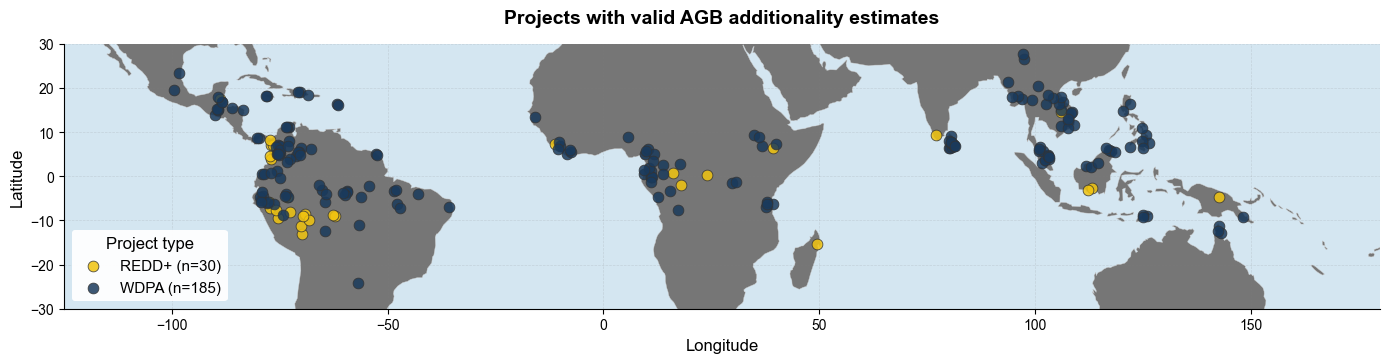

In [11]:
# Load and filter data
final_df = pd.read_csv(OUTPUT_CSV)
final_df = final_df[final_df['diff_rate_project'].notna()]
valid_project_ids = set(final_df['project_id'].unique())
filtered_metadata = final_df[final_df['project_id'].isin(valid_project_ids)].copy()

# REDD+ = numeric project IDs
filtered_metadata['is_redd'] = filtered_metadata['project_id'].apply(lambda x: str(x).isnumeric())

# Load centroids from GeoJSON
for project_id in filtered_metadata['project_id']:
    geojson_path = META_DIR / f'{project_id}.geojson'
    if geojson_path.exists():
        gdf = gpd.read_file(geojson_path)
        centroid = gdf.geometry.centroid.iloc[0]
        filtered_metadata.loc[filtered_metadata['project_id'] == project_id, 'lon'] = centroid.x
        filtered_metadata.loc[filtered_metadata['project_id'] == project_id, 'lat'] = centroid.y

# Build GeoDataFrame
geometry = [Point(xy) for xy in zip(filtered_metadata['lon'], filtered_metadata['lat'])]
projects_gdf = gpd.GeoDataFrame(filtered_metadata, geometry=geometry, crs='EPSG:4326')

# Basemap (world land)
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
world = world.to_crs(epsg=4326)
world_tropics = world[(world.geometry.bounds['miny'] < 30) & (world.geometry.bounds['maxy'] > -30)].copy()

# Plot
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('#d4e6f1')
world_tropics.plot(ax=ax, color='#767676', edgecolor='#cccccc', linewidth=0.3)

color_map = {True: '#f1c40f', False: '#1a3a5c'}
label_map = {True: 'REDD+', False: 'WDPA'}

for is_redd, color in color_map.items():
    mask = projects_gdf['is_redd'] == is_redd
    subset = projects_gdf[mask]
    if not subset.empty:
        ax.scatter(subset['lon'], subset['lat'], c=color, s=60, alpha=0.85,
                  edgecolor='#333333', linewidth=0.6,
                  label=f'{label_map[is_redd]} (n={mask.sum()})', zorder=5)

ax.set_xlim(-125, 180)
ax.set_ylim(-30, 30)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Projects with valid AGB additionality estimates', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, color='gray')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend = ax.legend(loc='lower left', fontsize=11, framealpha=0.9, edgecolor='none',
                   facecolor='white', title='Project type', title_fontsize=12)
legend.get_frame().set_alpha(0.95)
plt.tight_layout()
plt.show()

## 5. Local Spillover Heatmap

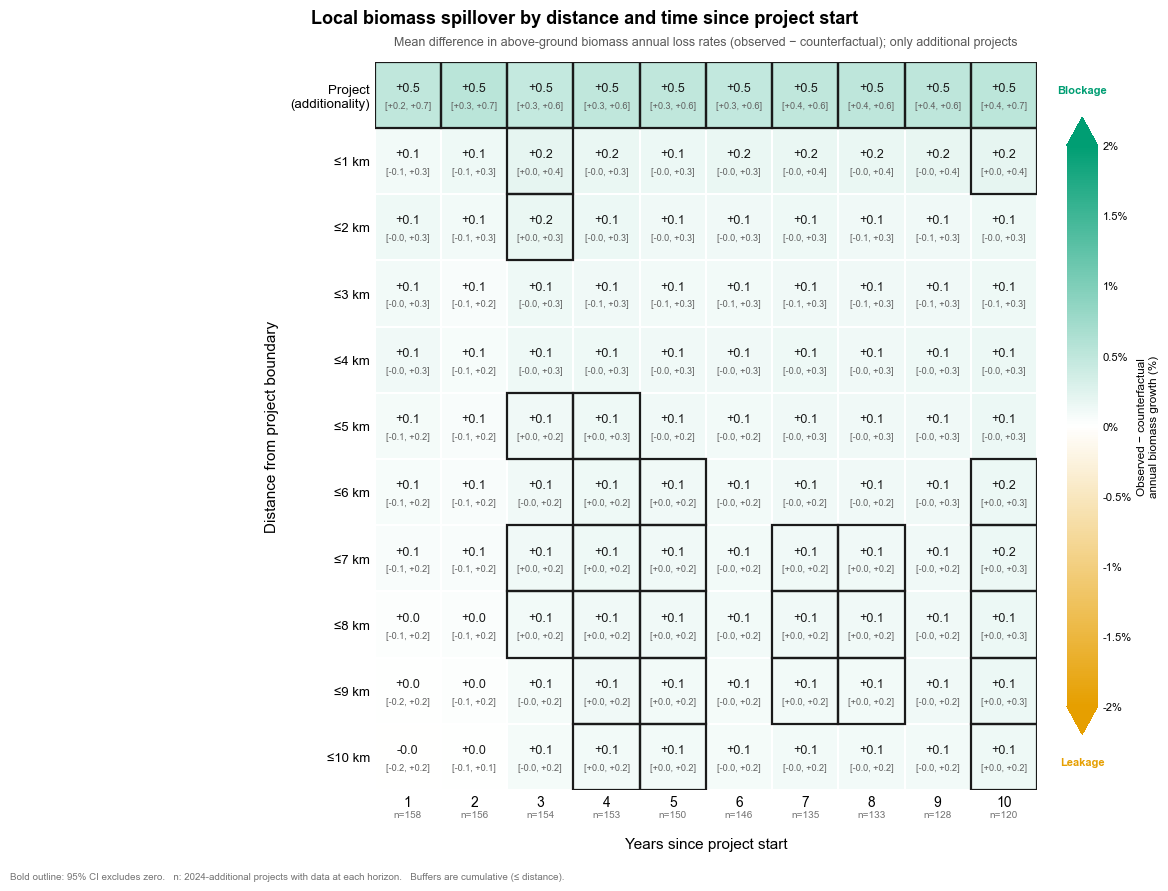

In [18]:
# --------------------- CONFIGURATION ---------------------
T_MIN, T_MAX = 1, 10
SUCCESS_ZONE = 'project'
SUCCESS_YEAR = 2024
INCLUDE_PROJECT_ROW = True
BUFFER_KEEP_STEP = 1000
ALPHA = 0.05
SHOW_CI = True
PCT = 100.0
COLOR_LIM = 2.0
# --------------------------------------------------------

OUT_MEAN = OUT_DIR / 'local_spillover_matrix_mean_pct.csv'
OUT_CILO = OUT_DIR / 'local_spillover_matrix_ci_low_pct.csv'
OUT_CIHI = OUT_DIR / 'local_spillover_matrix_ci_high_pct.csv'
OUT_N = OUT_DIR / 'local_spillover_matrix_n.csv'
OUT_PDF = OUT_DIR / 'local_spillover_heatmap.pdf'
OUT_PNG = OUT_DIR / 'local_spillover_heatmap.png'


def mean_ci(values, alpha=ALPHA):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    n = len(v)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    m = v.mean()
    if n == 1:
        return m, np.nan, np.nan, 1
    se = v.std(ddof=1) / np.sqrt(n)
    crit = stats.t.ppf(1 - alpha / 2, n - 1)
    h = crit * se
    return m, m - h, m + h, n


def build_matrices(df):
    parsed = {c: parse_col(c) for c in df.columns}
    parsed = {c: p for c, p in parsed.items() if p is not None}
    if not parsed:
        raise ValueError('No AGB columns found in the wide CSV.')

    zones = sorted({z for (z, _, _) in parsed.values()})
    buffer_zones = sorted((z for z in zones if z.startswith('buffer_')), key=buffer_distance)
    buffer_zones = [z for z in buffer_zones if buffer_distance(z) % BUFFER_KEEP_STEP == 0]
    row_zones = ([SUCCESS_ZONE] if INCLUDE_PROJECT_ROW else []) + buffer_zones

    cols_by = {}
    for c, (z, met, y) in parsed.items():
        cols_by.setdefault((z, met), []).append((y, c))

    def agb(row, zone, year, metric):
        return row.get(f'{zone}_{metric}_agb_{year}', np.nan)

    elapsed = list(range(T_MIN, T_MAX + 1))
    diffs = {t: {z: [] for z in row_zones} for t in elapsed}
    n_success = {t: 0 for t in elapsed}

    cohort = 0
    for _, row in df.iterrows():
        obs_years = sorted(y for (y, c) in cols_by.get((SUCCESS_ZONE, 'obs'), [])
                          if pd.notna(row[c]))
        if not obs_years:
            continue
        start = obs_years[0]

        def spillover(zone, end):
            delta = end - start
            r_obs = cagr(agb(row, zone, start, 'obs'), agb(row, zone, end, 'obs'), delta)
            r_cf = cagr(agb(row, zone, start, 'cf'), agb(row, zone, end, 'cf'), delta)
            return np.nan if pd.isna(r_obs) or pd.isna(r_cf) else r_obs - r_cf

        add_success = spillover(SUCCESS_ZONE, SUCCESS_YEAR)
        if pd.isna(add_success) or add_success <= 0:
            continue
        cohort += 1

        for t in elapsed:
            end = start + t
            for z in row_zones:
                val = spillover(z, end)
                if z == SUCCESS_ZONE and pd.notna(val):
                    n_success[t] += 1
                diffs[t][z].append(val)

    col_labels = [f't{t}' for t in elapsed]
    mean_mat = pd.DataFrame(index=row_zones, columns=col_labels, dtype=float)
    lo_mat = mean_mat.copy()
    hi_mat = mean_mat.copy()

    for t, lab in zip(elapsed, col_labels):
        for z in row_zones:
            m, lo, hi, n = mean_ci(diffs[t][z])
            mean_mat.at[z, lab] = m * PCT
            lo_mat.at[z, lab] = lo * PCT
            hi_mat.at[z, lab] = hi * PCT

    def row_label(z):
        if z == SUCCESS_ZONE:
            return 'Project\n(additionality)'
        return f'\u2264{buffer_distance(z) / 1000:g} km'

    pretty = [row_label(z) for z in row_zones]
    for mat in (mean_mat, lo_mat, hi_mat):
        mat.index = pretty

    return mean_mat, lo_mat, hi_mat, n_success, elapsed


def plot_spillover_heatmap(mean_mat, lo_mat, hi_mat, n_success, elapsed, lim=COLOR_LIM):
    row_labels = list(mean_mat.index)
    nrows, ncols = mean_mat.shape

    cmap = LinearSegmentedColormap.from_list('leak_block', [C_LEAK, '#ffffff', C_BLOCK])
    cmap.set_bad('#f4f4f4')
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)

    fig_w = 2.4 + 0.92 * ncols
    fig_h = 1.9 + 0.60 * nrows
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

    data = np.ma.masked_invalid(mean_mat.values.astype(float))
    mesh = ax.pcolormesh(data, cmap=cmap, norm=norm, edgecolors='white', linewidth=1.4)

    ax.set_aspect('equal')
    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels([str(t) for t in elapsed], fontsize=10)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_yticklabels(row_labels, fontsize=9.5)
    ax.invert_yaxis()
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xlabel('Years since project start', fontsize=11, labelpad=20)
    ax.set_ylabel('Distance from project boundary', fontsize=11, labelpad=8)

    for j, t in enumerate(elapsed):
        ax.text(j + 0.5, nrows + 0.30, f'n={int(n_success[t])}',
                ha='center', va='top', fontsize=7.2, color='0.45', clip_on=False)

    for i in range(nrows):
        for j in range(ncols):
            m = mean_mat.iat[i, j]
            if pd.isna(m):
                ax.text(j + 0.5, i + 0.5, '\u2013', ha='center', va='center', fontsize=9, color='0.6')
                continue
            lo, hi = lo_mat.iat[i, j], hi_mat.iat[i, j]
            ax.text(j + 0.5, i + 0.40, f'{m:+.1f}', ha='center', va='center', fontsize=9, color='#1a1a1a')
            if SHOW_CI and pd.notna(lo) and pd.notna(hi):
                ax.text(j + 0.5, i + 0.66, f'[{lo:+.1f}, {hi:+.1f}]',
                        ha='center', va='center', fontsize=6.6, color='0.38')
                if lo > 0 or hi < 0:
                    ax.add_patch(mpatches.Rectangle((j, i), 1, 1, fill=False,
                                   edgecolor='#1a1a1a', linewidth=1.6, zorder=5))

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.030, pad=0.02, extend='both')
    cbar.set_label('Observed \u2212 counterfactual\nannual biomass growth (%)', fontsize=8.5)
    cbar.formatter = mticker.FuncFormatter(lambda v, _: f'{v:g}%')
    cbar.update_ticks()
    cbar.ax.tick_params(length=0, labelsize=8)
    cbar.outline.set_visible(False)
    cbar.ax.text(0.5, 1.09, 'Blockage', transform=cbar.ax.transAxes,
                 ha='center', va='bottom', fontsize=8, color=C_BLOCK, fontweight='semibold')
    cbar.ax.text(0.5, -0.09, 'Leakage', transform=cbar.ax.transAxes,
                 ha='center', va='top', fontsize=8, color=C_LEAK, fontweight='semibold')

    fig.suptitle('Local biomass spillover by distance and time since project start',
                 fontsize=13, fontweight='semibold')
    ax.set_title('Mean difference in above-ground biomass annual loss rates '
                 f'(observed \u2212 counterfactual); only additional projects',
                 fontsize=9, color='0.35', pad=12)

    fig.text(0.005, -0.02,
             'Bold outline: 95% CI excludes zero.   '
             f'n: {SUCCESS_YEAR}-additional projects with data at each horizon.   '
             'Buffers are cumulative (\u2264 distance).',
             fontsize=7.0, color='0.45', ha='left', va='top')

    for p in [OUT_PDF, OUT_PNG]:
        fig.savefig(p, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


df_wide = pd.read_csv(WIDE_CSV)
mean_mat, lo_mat, hi_mat, n_success, elapsed = build_matrices(df_wide)

mean_mat.to_csv(OUT_MEAN)
lo_mat.to_csv(OUT_CILO)
hi_mat.to_csv(OUT_CIHI)

plot_spillover_heatmap(mean_mat, lo_mat, hi_mat, n_success, elapsed)

## 6. Quadrant Plot: Intervention vs Whole Buffer

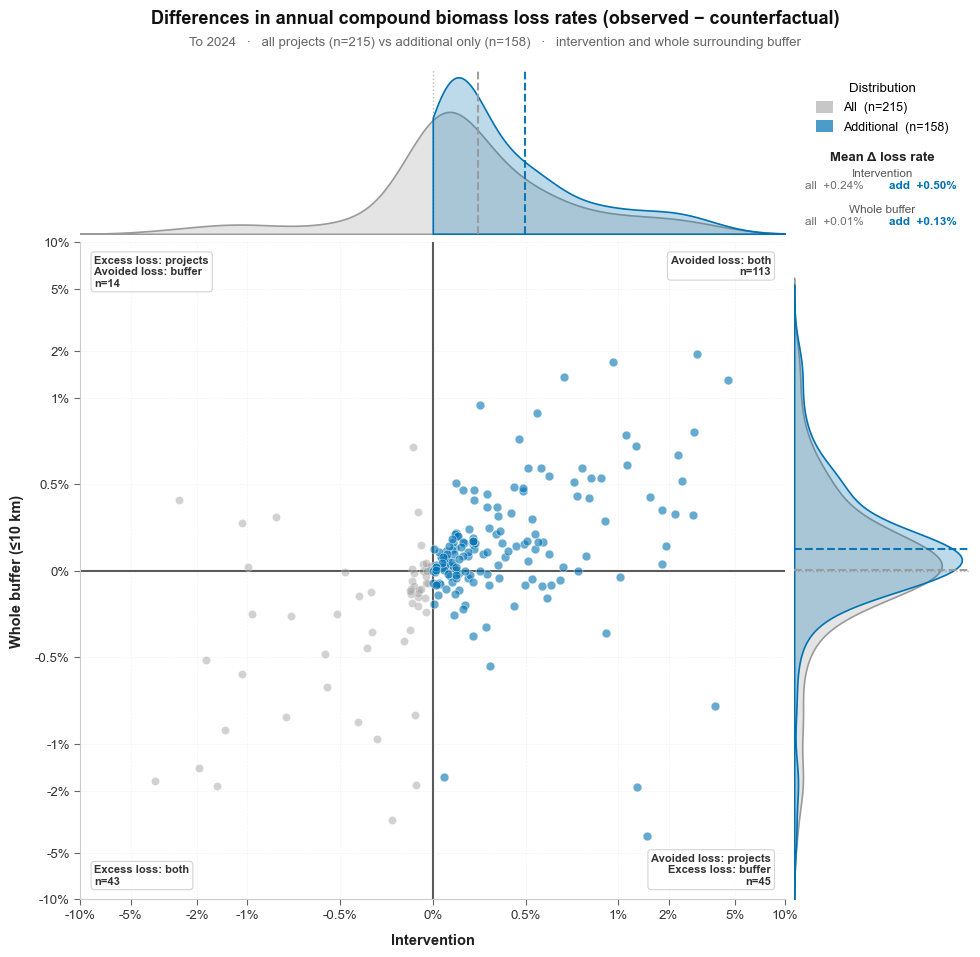

In [19]:
# Load data
DIFF_RATES_CSV = Path('./agb_outputs/all_projects_diff_rates.csv')
BUFFER_COL = 'diff_rate_buffer_whole'
END_YEAR = 2024

plot_df = pd.read_csv(DIFF_RATES_CSV)
plot_df = plot_df[['diff_rate_project', BUFFER_COL]].dropna()
plot_df = plot_df.rename(columns={'diff_rate_project': 'diff_rates_project',
                                   BUFFER_COL: 'diff_rates_buffer'})

add_df = plot_df[plot_df['diff_rates_project'] > 0].reset_index(drop=True)
n_all, n_add = len(plot_df), len(add_df)

LIN_THRESH = 0.01
LIN_SCALE = 1.0
AXIS_LIM = 0.10
TICKS = [-0.10, -0.05, -0.02, -0.01, -0.005, 0.0, 0.005, 0.01, 0.02, 0.05, 0.10]


def get_quadrant_counts(df, xcol, ycol):
    x, y = df[xcol], df[ycol]
    return {
        'q1': int(((x > 0) & (y > 0)).sum()),
        'q2': int(((x < 0) & (y > 0)).sum()),
        'q3': int(((x < 0) & (y < 0)).sum()),
        'q4': int(((x > 0) & (y < 0)).sum()),
    }


def format_additionality_label(v):
    return 'n/a' if pd.isna(v) else f'{v * 100:+.2f}%'


# Figure
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.02, wspace=0.02)

ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_rgt = fig.add_subplot(gs[1, 1], sharey=ax)
ax_leg = fig.add_subplot(gs[0, 1])

for ax_m in [ax_top, ax_rgt, ax_leg]:
    ax_m.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    for sp in ax_m.spines.values():
        sp.set_visible(False)
    ax_m.set_facecolor('white')
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)

# Main axis
ax.set_xlim(-AXIS_LIM, AXIS_LIM)
ax.set_ylim(-AXIS_LIM, AXIS_LIM)
ax.set_xscale('symlog', linthresh=LIN_THRESH, linscale=LIN_SCALE)
ax.set_yscale('symlog', linthresh=LIN_THRESH, linscale=LIN_SCALE)
ax.set_xticks(TICKS)
ax.xaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.set_yticks(TICKS)
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.tick_params(axis='both', labelsize=9.5, length=4, width=0.8, direction='out',
               color='#666666', labelcolor='#333333')
ax.grid(True, alpha=0.12, linestyle='--', linewidth=0.5, color='#999999', zorder=0)
for sp in ['bottom', 'left']:
    ax.spines[sp].set_color('#CCCCCC')
    ax.spines[sp].set_linewidth(0.8)

ax.axhline(0, color='#222222', linewidth=1.5, alpha=0.75, zorder=1)
ax.axvline(0, color='#222222', linewidth=1.5, alpha=0.75, zorder=1)
ax_top.axvline(0, color='#AAAAAA', linewidth=1.0, alpha=0.8, zorder=2, linestyle=':')
ax_rgt.axhline(0, color='#AAAAAA', linewidth=1.0, alpha=0.8, zorder=2, linestyle=':')

# Scatter
is_add = plot_df['diff_rates_project'] > 0
ax.scatter(plot_df.loc[~is_add, 'diff_rates_project'],
           plot_df.loc[~is_add, 'diff_rates_buffer'],
           c=C_ALL, alpha=0.45, s=34, edgecolors='white', linewidth=0.4, zorder=5)
ax.scatter(plot_df.loc[is_add, 'diff_rates_project'],
           plot_df.loc[is_add, 'diff_rates_buffer'],
           c=C_ADD, alpha=0.60, s=40, edgecolors='white', linewidth=0.5, zorder=6)

# Quadrant labels
qc = get_quadrant_counts(plot_df, 'diff_rates_project', 'diff_rates_buffer')
_bb = dict(boxstyle='round,pad=0.30', facecolor='white', alpha=0.85, edgecolor='#CCCCCC', linewidth=0.8)
_qlabels = [
    (f'Excess loss: both\nn={qc["q3"]}', 0.02, 0.02, 'left', 'bottom'),
    (f'Excess loss: projects\nAvoided loss: buffer\nn={qc["q2"]}', 0.02, 0.98, 'left', 'top'),
    (f'Avoided loss: projects\nExcess loss: buffer\nn={qc["q4"]}', 0.98, 0.02, 'right', 'bottom'),
    (f'Avoided loss: both\nn={qc["q1"]}', 0.98, 0.98, 'right', 'top'),
]
for txt, xf, yf, ha, va in _qlabels:
    ax.text(xf, yf, txt, transform=ax.transAxes, fontsize=8, ha=ha, va=va,
            fontweight='semibold', color='#333333', bbox=_bb, zorder=7)

# Marginal KDEs
full = (-AXIS_LIM, AXIS_LIM)
sns.kdeplot(data=plot_df, x='diff_rates_project', ax=ax_top,
            fill=True, alpha=0.26, color=C_ALL, linewidth=1.2, clip=full, zorder=3)
sns.kdeplot(data=add_df, x='diff_rates_project', ax=ax_top,
            fill=True, alpha=0.26, color=C_ADD, linewidth=1.2, clip=(0.0, AXIS_LIM), zorder=4)
sns.kdeplot(data=plot_df, y='diff_rates_buffer', ax=ax_rgt,
            fill=True, alpha=0.26, color=C_ALL, linewidth=1.2, clip=full, zorder=3)
sns.kdeplot(data=add_df, y='diff_rates_buffer', ax=ax_rgt,
            fill=True, alpha=0.26, color=C_ADD, linewidth=1.2, clip=full, zorder=4)

# Mean lines
mean_i_all = plot_df['diff_rates_project'].mean()
mean_i_add = add_df['diff_rates_project'].mean()
mean_b_all = plot_df['diff_rates_buffer'].mean()
mean_b_add = add_df['diff_rates_buffer'].mean()

ax_top.axvline(mean_i_all, color=C_ALL, ls='--', lw=1.5, alpha=0.95, zorder=5)
ax_top.axvline(mean_i_add, color=C_ADD, ls='--', lw=1.5, alpha=0.95, zorder=6)
ax_rgt.axhline(mean_b_all, color=C_ALL, ls='--', lw=1.5, alpha=0.95, zorder=5)
ax_rgt.axhline(mean_b_add, color=C_ADD, ls='--', lw=1.5, alpha=0.95, zorder=6)

# Legend
handles = [mpatches.Patch(facecolor=C_ALL, edgecolor='none', alpha=0.55),
           mpatches.Patch(facecolor=C_ADD, edgecolor='none', alpha=0.70)]
labels = [f'All  (n={n_all})', f'Additional  (n={n_add})']
ax_leg.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99),
              frameon=False, fontsize=9, handlelength=1.3, handleheight=1.1,
              title='Distribution', title_fontsize=9.5)

ax_leg.text(0.5, 0.50, 'Mean \u0394 loss rate', ha='center', va='top',
            fontsize=9.5, fontweight='bold', color='#222222')

def _mean_row(y, label, m_all, m_add):
    ax_leg.text(0.5, y, label, ha='center', va='top', fontsize=8.5, color='#555555')
    ax_leg.text(0.06, y - 0.075, f'all  {format_additionality_label(m_all)}',
                ha='left', va='top', fontsize=8.5, color='#6E6E6E')
    ax_leg.text(0.54, y - 0.075, f'add  {format_additionality_label(m_add)}',
                ha='left', va='top', fontsize=8.5, color=C_ADD, fontweight='semibold')

_mean_row(0.40, 'Intervention', mean_i_all, mean_i_add)
_mean_row(0.18, 'Whole buffer', mean_b_all, mean_b_add)

# Axis labels
ax.set_xlabel('Intervention', fontsize=10.5, labelpad=8, color='#222222', fontweight='bold')
ax.set_ylabel('Whole buffer (\u226410 km)', fontsize=10.5, labelpad=8, color='#222222', fontweight='bold')

fig.text(0.5, 0.965,
         'Differences in annual compound biomass loss rates (observed \u2212 counterfactual)',
         ha='center', va='top', fontsize=13, fontweight='semibold', color='#111111')
fig.text(0.5, 0.938,
         f'To {END_YEAR}   \u00b7   all projects (n={n_all}) vs additional only (n={n_add})   '
         '\u00b7   intervention and whole surrounding buffer',
         ha='center', va='top', fontsize=9.5, color='0.40')

fig.subplots_adjust(left=0.085, right=0.975, top=0.905, bottom=0.075)

for fmt, dpi in [('png', 300), ('pdf', None)]:
    kw = dict(bbox_inches='tight', facecolor='white', edgecolor='none')
    if dpi:
        kw['dpi'] = dpi
    fig.savefig(OUT_DIR / f'diff_rates_quadrant_symlog_wholebuffer_{END_YEAR}.{fmt}', **kw)
plt.show()

## 7. Panel C: Spillover vs Additionality

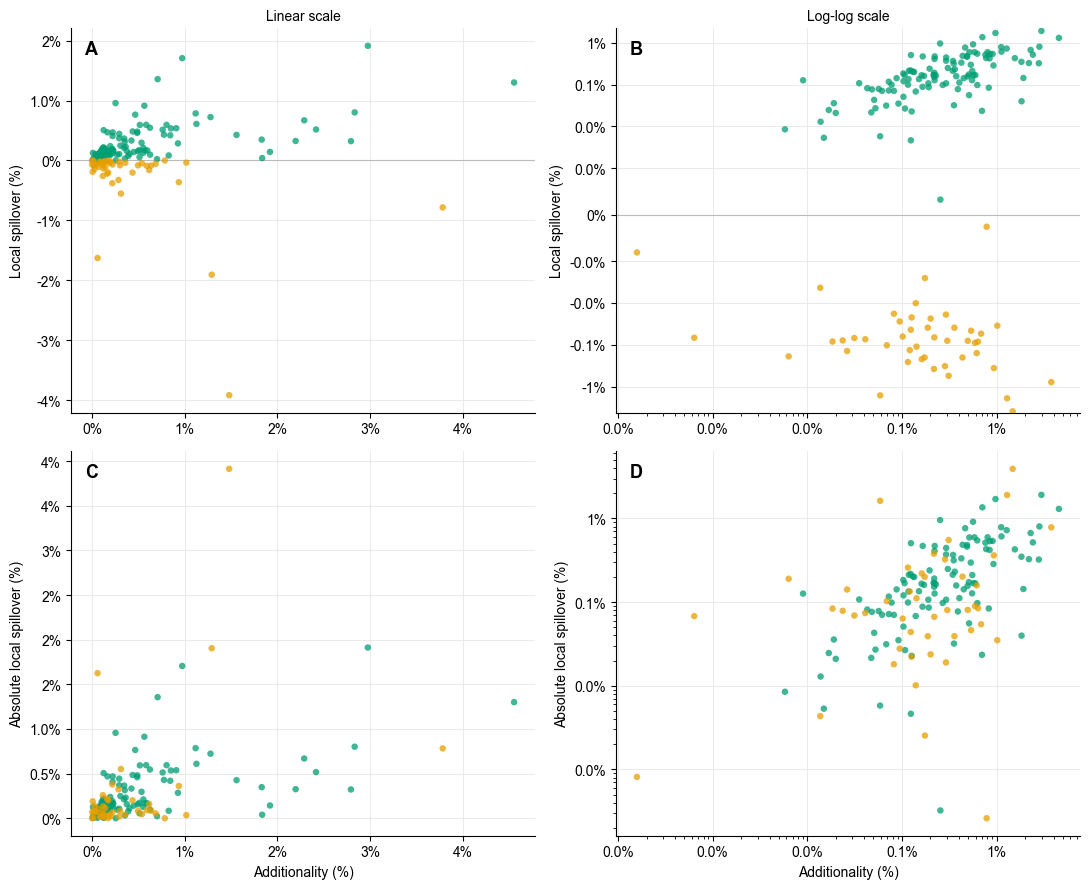

In [20]:
def panel_plot(ax, logscale, signed, show_xlabel, label):
    d = plot_df.copy()
    d = d[(d['diff_rates_project'] > 0) & (d['diff_rates_buffer'] != 0)]
    x = d['diff_rates_project'].to_numpy()
    y = d['diff_rates_buffer'].to_numpy()
    block, leak = y > 0, y < 0
    yvals = y if signed else np.abs(y)

    ax.scatter(x[block], yvals[block], s=22, c=C_BLOCK, alpha=0.75, edgecolor='none', zorder=4)
    ax.scatter(x[leak], yvals[leak], s=22, c=C_LEAK, alpha=0.75, edgecolor='none', zorder=4)

    if signed:
        ax.axhline(0, color='#bbbbbb', lw=0.8)

    if logscale:
        ax.set_xscale('log')
        if signed:
            ax.set_yscale('symlog', linthresh=1e-5)
        else:
            ax.set_yscale('log')
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    else:
        pass

    ax.xaxis.set_major_formatter(FuncFormatter(pct_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
    if show_xlabel:
        ax.set_xlabel('Additionality (%)')
    ax.set_ylabel('Local spillover (%)' if signed else 'Absolute local spillover (%)')
    ax.grid(True, which='major', color='#e6e6e6', lw=0.6)
    ax.set_axisbelow(True)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.text(0.03, 0.97, label, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='left')


fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panel_plot(axes[0, 0], False, True, False, 'A')
panel_plot(axes[0, 1], True, True, False, 'B')
panel_plot(axes[1, 0], False, False, True, 'C')
panel_plot(axes[1, 1], True, False, True, 'D')

axes[0, 0].set_title('Linear scale', fontsize=10)
axes[0, 1].set_title('Log-log scale', fontsize=10)

fig.tight_layout()
fig.savefig(OUT_DIR / 'panel_c_2x2.png', dpi=300)
fig.savefig(OUT_DIR / 'panel_c_2x2.pdf')
plt.show()

## 8. Bayesian Logistic Regression

Initializing NUTS using jitter+adapt_diag...
/home/jh2589/gis_env/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, mu_alpha, sigma_alpha, alpha_raw]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.


Output()

/home/jh2589/gis_env/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/jh2589/gis_env/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
Sampling: [y_obs]


Output()

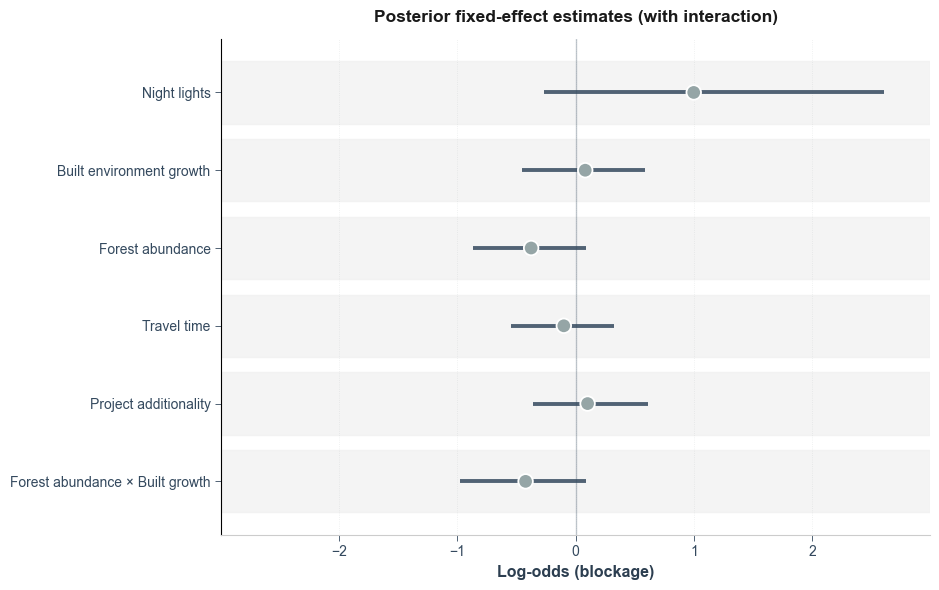

WAIC = 183.57 (SE: 12.48)
LOO = 184.13 (SE: 12.56)
In-sample accuracy: 0.722
ROC-AUC: 0.646


In [21]:
# Load data
df = pd.read_csv(COVARIATES_CSV)
df = df[df['diff_rate_buffer_whole'] != 0].copy()
df['blockage'] = (df['diff_rate_buffer_whole'] > 0).astype(int)

# Rename columns to match model
df = df.rename(columns={
    'ghsl_built_pct_change': 'built_growth',
    'forest_prop_buffer': 'forest_abundance'
})

predictor_cols = ['night_lights', 'built_growth', 'forest_abundance', 'travel_time', 'diff_rate_project']

# Handle missing data
df_clean = df.dropna(subset=predictor_cols + ['blockage', 'iucn_cat']).copy()

# Standardise continuous predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[predictor_cols])
X_df = pd.DataFrame(X_scaled, columns=predictor_cols, index=df_clean.index)

# Interaction term
X_df['interaction_forest_built'] = X_df['forest_abundance'] * X_df['built_growth']

predictor_cols_full = predictor_cols + ['interaction_forest_built']
X_full = X_df[predictor_cols_full].values

y = df_clean['blockage'].values
groups = df_clean['iucn_cat'].astype('category')
group_idx = groups.cat.codes.values
n_groups = len(groups.cat.categories)

# Build PyMC model
with pm.Model() as model:
    beta = pm.Normal('beta', mu=0, sigma=2, shape=len(predictor_cols_full))
    mu_alpha = pm.Normal('mu_alpha', mu=0, sigma=1)
    sigma_alpha = pm.HalfCauchy('sigma_alpha', beta=1)
    alpha_raw = pm.Normal('alpha_raw', mu=0, sigma=1, shape=n_groups)
    alpha = pm.Deterministic('alpha', mu_alpha + sigma_alpha * alpha_raw)
    eta = alpha[group_idx] + pm.math.dot(X_full, beta)
    p = pm.Deterministic('p', pm.math.sigmoid(eta))
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y)
    trace = pm.sample(2000, tune=2000, chains=4, target_accept=0.9,
                      random_seed=42, return_inferencedata=True)

# Compute log-likelihood and model comparison
with model:
    idata = pm.compute_log_likelihood(trace, model=model)

waic = az.waic(idata)
loo = az.loo(idata)

# Summarise fixed effects
summary_beta = az.summary(trace, var_names=['beta'], hdi_prob=0.95)
summary_beta['predictor'] = predictor_cols_full

posterior_beta = trace.posterior['beta'].values
posterior_beta_flat = posterior_beta.reshape(-1, len(predictor_cols_full))
prob_positive = (posterior_beta_flat > 0).mean(axis=0)
summary_beta['prob_positive'] = prob_positive

summary_beta = summary_beta.rename(columns={
    'mean': 'Mean', 'sd': 'SD',
    'hdi_2.5%': '2.5%', 'hdi_97.5%': '97.5%'
})

# Random intercept
summary_sigma = az.summary(trace, var_names=['sigma_alpha'], hdi_prob=0.95)
random_intercept_row = pd.DataFrame({
    'predictor': ['sigma_alpha (IUCN)'],
    'Mean': [summary_sigma['mean'].values[0]],
    'SD': [summary_sigma['sd'].values[0]],
    '2.5%': [summary_sigma['hdi_2.5%'].values[0]],
    '97.5%': [summary_sigma['hdi_97.5%'].values[0]],
    'prob_positive': [np.nan]
})

reg_table = pd.concat([
    summary_beta[['predictor', 'Mean', 'SD', '2.5%', '97.5%', 'prob_positive']],
    random_intercept_row
], ignore_index=True)
reg_table.to_csv(OUT_DIR / 'regression_table.csv', index=False)

# Posterior predictive check
with model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)
pred_probs = ppc.posterior_predictive['y_obs'].mean(dim=['chain', 'draw']).values
pred_class = (pred_probs > 0.5).astype(int)
accuracy = (pred_class == y).mean()
auc = roc_auc_score(y, pred_probs)

# Forest plot
fig, ax = plt.subplots(figsize=(9.5, 6))

beta_rows = reg_table[reg_table['predictor'] != 'sigma_alpha (IUCN)']
y_pos = np.arange(len(beta_rows))
means = beta_rows['Mean'].values
lowers = beta_rows['2.5%'].values
uppers = beta_rows['97.5%'].values
labels = beta_rows['predictor'].values

label_map = {
    'night_lights': 'Night lights',
    'built_growth': 'Built environment growth',
    'forest_abundance': 'Forest abundance',
    'travel_time': 'Travel time',
    'diff_rate_project': 'Project additionality',
    'interaction_forest_built': 'Forest abundance \u00d7 Built growth'
}
labels_clean = [label_map.get(l, l) for l in labels]

for i, (l, u) in enumerate(zip(lowers, uppers)):
    if l <= 0 <= u:
        ax.axhspan(i - 0.4, i + 0.4, color='#f0f0f0', zorder=0, alpha=0.7)

ax.hlines(y_pos, lowers, uppers, color='#34495e', linewidth=2.8, alpha=0.85, zorder=2)
colors = np.where((lowers <= 0) & (0 <= uppers), '#95a5a6', '#e74c3c')
ax.scatter(means, y_pos, c=colors, s=110, zorder=3, edgecolor='white', linewidth=1.3)
ax.axvline(0, color='#34495e', linestyle='-', alpha=0.3, linewidth=1, zorder=1)
ax.grid(axis='x', linestyle=':', alpha=0.15, color='#7f8c8d', linewidth=0.6)
ax.set_axisbelow(True)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_clean, fontsize=11, color='#2c3e50')
ax.set_xlabel('Log-odds (blockage)', fontsize=11.5, fontweight='semibold', color='#2c3e50')
ax.set_title('Posterior fixed-effect estimates (with interaction)',
             fontsize=12.5, fontweight='semibold', color='#1a1a1a', pad=12)
ax.invert_yaxis()

x_lim = max(abs(lowers).max(), abs(uppers).max()) * 1.15
ax.set_xlim(-x_lim, x_lim)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', labelsize=10, colors='#34495e', length=4, width=0.6)

fig.tight_layout()
fig.savefig(OUT_DIR / 'forest_plot_publication.pdf', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'forest_plot_publication.png', dpi=300, bbox_inches='tight')
plt.show()

az.to_netcdf(trace, OUT_DIR / 'spillover_model_trace_with_interaction.nc')

print(f'WAIC = {waic.elpd_waic * -2:.2f} (SE: {waic.se * 2:.2f})')
print(f'LOO = {loo.elpd_loo * -2:.2f} (SE: {loo.se * 2:.2f})')
print(f'In-sample accuracy: {accuracy:.3f}')
print(f'ROC-AUC: {auc:.3f}')

## 9. Spatial Analysis and Hotspot Detection

In [22]:
def neutral_threshold(absvals, rule, value):
    if rule == 'fixed':
        return float(value)
    if rule == 'contribution':
        s = np.sort(absvals)
        if s.sum() == 0:
            return 0.0
        cum = np.cumsum(s) / s.sum()
        idx = int(np.searchsorted(cum, value, side='right'))
        return float(s[min(idx, len(s) - 1)])
    if rule == 'percentile':
        return float(np.percentile(absvals, value))
    if rule == 'mad':
        return float(value * np.median(absvals))
    raise ValueError(f'unknown neutral rule: {rule}')


def hotspots(intensity, w, permutations, alpha, seed):
    hot = np.zeros(len(intensity), dtype=bool)
    if np.count_nonzero(intensity) >= 3 and intensity.sum() > 0:
        g = G_Local(intensity, w, star=True, permutations=permutations, seed=seed)
        hot = (g.Zs > 0) & (g.p_sim < alpha)
    return hot


def get_chaos_metrics(project_id, out_dir, base_path='/scratch/jh2589/wdpa_leakage_analysis',
                      res=250, min_points=1, neutral_rule='contribution', neutral_value=0.05,
                      k_neighbours=8, permutations=999, alpha=0.05, seed=42):
    """Compute Getis-Ord Gi* hotspots for a single project."""
    result = {
        'blockage_cover': np.nan, 'leakage_cover': np.nan, 'total_cover': np.nan,
        'cover_diff': np.nan, 'cover_ratio': np.nan, 'cover_dominance': np.nan,
        'n_cells': 0, 'n_block': 0, 'n_leak': 0, 'n_overlap': 0,
        'global_mean': np.nan, 'neutral_threshold': np.nan, 'cell_area_ha': np.nan,
        'net_agb_t': np.nan, 'gross_agb_t': np.nan,
        'blockage_hot_agb_t': np.nan, 'leakage_hot_agb_t': np.nan,
        'blockage_frac_pos': np.nan, 'leakage_frac_neg': np.nan, 'agb_dominance': np.nan,
        'png_path': None, 'error': None,
    }

    project_folder = os.path.join(base_path, project_id)
    parquet_file = os.path.join(project_folder, 'all_pairs_buffer.parquet')
    carbon_file = os.path.join(project_folder, 'carbon-density.csv')

    if not (os.path.exists(parquet_file) and os.path.exists(carbon_file)):
        result['error'] = f'Missing files for project {project_id}'
        return result

    try:
        df = pd.read_parquet(parquet_file)
        carbon = pd.read_csv(carbon_file)
        agb_lookup = carbon.set_index('luc')['agb'].to_dict()

        df['k_agb_2024'] = df['k_luc_2024'].map(agb_lookup)
        for i in range(1, 5):
            if i not in agb_lookup:
                result['error'] = f'Missing AGB for luc={i} in project {project_id}'
                return result
            df[f's_agb_{i}_2024'] = df[f's_prop_{i}_2024'] * agb_lookup[i]
        df['s_agb_2024'] = df[[f's_agb_{i}_2024' for i in range(1, 5)]].sum(axis=1)
        df['k_agb_2024'] = df['k_agb_2024'].round(0)
        df['s_agb_2024'] = df['s_agb_2024'].round(0)
        df['diff_agb_2024'] = (df['k_agb_2024'] - df['s_agb_2024']).round(0)
        df = df[df['diff_agb_2024'] != 0].copy()
        if len(df) == 0:
            result['error'] = f'No non-zero diff values for project {project_id}'
            return result

        mean_lat = df['k_lat'].mean()
        utm_zone = int((df['k_lng'].mean() + 180) // 6) + 1
        epsg_code = (32600 if mean_lat >= 0 else 32700) + utm_zone
        utm = pyproj.Transformer.from_crs('EPSG:4326', f'EPSG:{epsg_code}', always_xy=True)
        df['x'], df['y'] = utm.transform(df['k_lng'].values, df['k_lat'].values)

        x_min, x_max = df['x'].min() - res, df['x'].max() + res
        y_min, y_max = df['y'].min() - res, df['y'].max() + res
        x_edges = np.arange(x_min, x_max + res, res)
        y_edges = np.arange(y_min, y_max + res, res)
        raster_mean, _, _, _ = binned_statistic_2d(df['x'], df['y'], df['diff_agb_2024'],
                                                    statistic='mean', bins=[x_edges, y_edges])
        raster_count, _, _, _ = binned_statistic_2d(df['x'], df['y'], df['diff_agb_2024'],
                                                     statistic='count', bins=[x_edges, y_edges])
        grid = raster_mean.T
        cnt = raster_count.T
        mask = (cnt < min_points) | np.isnan(grid)

        grid = grid.copy()
        absv = np.abs(grid[~mask])
        thr = neutral_threshold(absv, neutral_rule, neutral_value) if absv.size else 0.0
        grid[(~mask) & (np.abs(grid) < thr)] = 0.0
        result['neutral_threshold'] = thr

        valid = ~mask
        n_valid = int(valid.sum())
        if n_valid == 0:
            result['error'] = f'All cells masked for project {project_id}'
            return result

        x_cen = x_edges[:-1] + res / 2.0
        y_cen = y_edges[:-1] + res / 2.0
        iy, ix = np.where(valid)
        coords = np.column_stack([x_cen[ix], y_cen[iy]])
        vals = grid[iy, ix].astype(float)
        global_mean = float(vals.mean())

        if n_valid <= k_neighbours:
            result.update({'n_cells': n_valid, 'global_mean': global_mean,
                           'error': f'Too few valid cells ({n_valid}) for {project_id}'})
            return result

        w = KNN.from_array(coords, k=k_neighbours)
        w.transform = 'r'

        block_hot = hotspots(np.clip(vals, 0, None), w, permutations, alpha, seed)
        leak_hot = hotspots(np.clip(-vals, 0, None), w, permutations, alpha, seed)
        both = block_hot & leak_hot
        n_block, n_leak = int(block_hot.sum()), int(leak_hot.sum())
        n_either = int((block_hot | leak_hot).sum())
        blockage_cover = n_block / n_valid
        leakage_cover = n_leak / n_valid

        cell_area_ha = (res ** 2) / 10_000.0
        tot = vals * cell_area_ha
        pos_total = tot[tot > 0].sum()
        neg_total = tot[tot < 0].sum()
        blk_t = float(tot[block_hot].sum())
        lk_t = float(tot[leak_hot].sum())

        denom = blockage_cover + leakage_cover
        result.update({
            'blockage_cover': blockage_cover, 'leakage_cover': leakage_cover,
            'total_cover': n_either / n_valid,
            'cover_diff': blockage_cover - leakage_cover,
            'cover_ratio': (blockage_cover / leakage_cover) if leakage_cover > 0 else np.nan,
            'cover_dominance': ((blockage_cover - leakage_cover) / denom) if denom > 0 else np.nan,
            'n_cells': n_valid, 'n_block': n_block, 'n_leak': n_leak, 'n_overlap': int(both.sum()),
            'global_mean': global_mean, 'cell_area_ha': cell_area_ha,
            'net_agb_t': float(tot.sum()), 'gross_agb_t': float(np.abs(tot).sum()),
            'blockage_hot_agb_t': blk_t, 'leakage_hot_agb_t': lk_t,
            'blockage_frac_pos': blk_t / pos_total if pos_total > 0 else np.nan,
            'leakage_frac_neg': lk_t / neg_total if neg_total < 0 else np.nan,
            'agb_dominance': (blk_t + lk_t) / (blk_t - lk_t) if (blk_t - lk_t) != 0 else np.nan,
        })

        # Create map
        os.makedirs(out_dir, exist_ok=True)
        cat = np.zeros(grid.shape, dtype=int)
        cat[iy[block_hot], ix[block_hot]] = 1
        cat[iy[leak_hot], ix[leak_hot]] = 2
        cat[iy[both], ix[both]] = 3
        diff_plot = np.ma.masked_where(mask, grid)
        cat_plot = np.ma.masked_where(~valid, cat)

        inv = pyproj.Transformer.from_crs(f'EPSG:{epsg_code}', 'EPSG:4326', always_xy=True)
        XX, YY = np.meshgrid(x_edges, y_edges)
        LON, LAT = inv.transform(XX, YY)
        vmax = float(np.nanmax(np.abs(vals))) or 1.0

        diverging = LinearSegmentedColormap.from_list('leak_block', [C_LEAK, '#E8E7DF', C_BLOCK])
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))

        pm = ax1.pcolormesh(LON, LAT, diff_plot, cmap=diverging,
                            norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax), shading='flat')
        ax1.set_title('Observed \u2212 counterfactual AGB (2024)', fontsize=11, fontweight='bold', pad=8)
        cb = fig.colorbar(pm, ax=ax1, fraction=0.046, pad=0.04)
        cb.set_label('AGB difference (t ha$^{-1}$)', fontsize=9)
        cb.ax.tick_params(labelsize=8)
        cb.outline.set_visible(False)

        colors = ['#E8E7DF', C_BLOCK, C_LEAK, '#BE56E1']
        cmap2 = ListedColormap(colors)
        norm2 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap2.N)
        ax2.pcolormesh(LON, LAT, cat_plot, cmap=cmap2, norm=norm2, shading='flat')
        ax2.set_title(f'Local spillover hotspots (Getis-Ord Gi*, p < {alpha:.2f})',
                      fontsize=11, fontweight='bold', pad=8)
        labels = ['Blockage', 'Leakage', 'Both']
        ax2.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors[1:], labels)],
                   fontsize=8.5, loc='upper right', framealpha=0.95, edgecolor='none',
                   title='Hotspot type', title_fontsize=9)

        for ax in (ax1, ax2):
            ax.set_xlabel('Longitude', fontsize=10)
            ax.set_ylabel('Latitude', fontsize=10)
            ax.tick_params(labelsize=8.5)
            ax.set_aspect(1.0 / np.cos(np.deg2rad(mean_lat)))

        for ax, lab in zip((ax1, ax2), ('A', 'B')):
            ax.text(-0.08, 1.04, lab, transform=ax.transAxes,
                    fontsize=14, fontweight='bold', va='bottom', ha='right')

        fig.tight_layout()
        png_path = os.path.join(out_dir, f'{project_id}_gistar.png')
        pdf_path = os.path.join(out_dir, f'{project_id}_gistar.pdf')
        fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
        fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        result['png_path'] = png_path
        result['pdf_path'] = pdf_path

    except Exception as e:
        result['error'] = f'Exception: {str(e)}'

    return result

## 10. Cover Dominance Analysis

In [27]:
def compute_areas():
    EQUAL_AREA_CRS = 'EPSG:6933'
    positive_effects_df = pd.read_csv(OUTPUT_CSV)
    positive_effects_df = positive_effects_df[positive_effects_df['diff_rate_project'] > 0].copy()

    for project_id in positive_effects_df['project_id']:
        buffer_path = os.path.join(BASE_DIR, project_id, 'buffered_project.geojson')
        if os.path.exists(buffer_path):
            buffer_gdf = gpd.read_file(buffer_path)
            buffer_gdf = buffer_gdf.to_crs(EQUAL_AREA_CRS)
            buffer_gdf['geometry'] = buffer_gdf.geometry.buffer(0)
            area_ha = buffer_gdf.geometry.area.sum() / 10_000.0
            positive_effects_df.loc[positive_effects_df['project_id'] == project_id, 'buffer_area_ha'] = area_ha

        project_area_path = os.path.join(META_DIR, f'{project_id}.geojson')
        if os.path.exists(project_area_path):
            try:
                gdf = gpd.read_file(project_area_path)
                if gdf.crs is None:
                    gdf = gdf.set_crs('EPSG:4326')
                gdf_projected = gdf.to_crs(EQUAL_AREA_CRS)
                area_ha = gdf_projected.geometry.area.sum() / 10_000.0
                positive_effects_df.loc[positive_effects_df['project_id'] == project_id, 'project_area_ha'] = area_ha
            except Exception:
                pass

    return positive_effects_df


positive_effects_df = compute_areas()

# Plot cover dominance
cd = positive_effects_df['cover_diff'].dropna() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# Panel A: Distribution
ax = axes[0]
ax.hist(cd, bins=28, color='#6699CC', alpha=0.55, density=True,
        edgecolor='white', linewidth=0.6)
kde = gaussian_kde(cd)
x_kde = np.linspace(cd.min(), cd.max(), 300)
ax.plot(x_kde, kde(x_kde), color='#264653', linewidth=2)
ax.axvline(cd.mean(), color='#D55E00', linestyle='--', linewidth=1.8)
ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Local spillover difference (%)', fontsize=10, fontweight='semibold')
ax.set_ylabel('Density', fontsize=10, fontweight='semibold')
ax.set_title('A: Distribution of spillover difference', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.12, axis='y')
ax.set_axisbelow(True)

# Panel B: Difference vs signed spillover
ax = axes[1]
df_xy = positive_effects_df[['diff_rate_buffer_whole', 'cover_diff']].dropna()
df_xy = df_xy.copy()
df_xy['spillover_pct'] = df_xy['diff_rate_buffer_whole'] * 100
df_xy['cover_diff'] = df_xy['cover_diff'] * 100

slope, intercept, r_val, p_val, se = linregress(df_xy['spillover_pct'], df_xy['cover_diff'])

pos = df_xy['spillover_pct'] >= 0
ax.scatter(df_xy.loc[pos, 'spillover_pct'], df_xy.loc[pos, 'cover_diff'],
           alpha=0.65, s=38, color=C_BLOCK, edgecolors='white', linewidth=0.5)
ax.scatter(df_xy.loc[~pos, 'spillover_pct'], df_xy.loc[~pos, 'cover_diff'],
           alpha=0.65, s=38, color=C_LEAK, edgecolors='white', linewidth=0.5)

x_vals = np.linspace(df_xy['spillover_pct'].min(), df_xy['spillover_pct'].max(), 100)
ax.plot(x_vals, slope * x_vals + intercept, color='#D55E00', linestyle='--', linewidth=2)
ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)

ax.set_xlabel('10km buffer local spillover (%)', fontsize=10, fontweight='semibold')
ax.set_ylabel('Local spillover area difference (%)', fontsize=10, fontweight='semibold')
ax.set_title('B: Difference vs signed spillover', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.12)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(OUT_DIR / 'cover_dominance_panel_AB.png', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'cover_dominance_panel_AB.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'n = {len(df_xy)}')
print(f'Mean dominance = {cd.mean():.4f}')
print(f'Dominance vs signed spillover: slope = {slope:.4f}, R\u00b2 = {r_val**2:.3f}, p = {p_val:.4e}')

KeyError: 'cover_diff'

## 11. Supplementary Table

In [28]:
def _direction(v):
    if pd.isna(v) or v == 0:
        return ''
    return 'Blockage' if v > 0 else 'Leakage'


def build_supp_table():
    base = pd.read_csv(OUTPUT_CSV)
    base = base[base['diff_rate_project'].notna()].reset_index(drop=True)

    ids = base['project_id'].astype(str)
    tab = pd.DataFrame({
        'project_id': base['project_id'],
        'type': np.where(ids.str.isnumeric(), 'REDD+', 'WDPA'),
        'start_year': base['start_year'].astype('Int64'),
        'end_year': base['end_year'].astype('Int64'),
        'n_years': (base['end_year'] - base['start_year']).astype('Int64'),
        'additional': np.where(base['diff_rate_project'] > 0, 'Yes', 'No'),
        'additionality_pct': base['diff_rate_project'] * PCT,
        'buffer_spillover_pct': base['diff_rate_buffer_whole'] * PCT,
        'buffer_direction': base['diff_rate_buffer_whole'].apply(_direction),
        'diff_rate_project': base['diff_rate_project'],
    })
    tab['project_id'] = tab['project_id'].astype(str)

    # Merge metadata
    meta_path = OUT_DIR / 'positive_additionality_projects' / 'positive_additionality_metadata.csv'
    if meta_path.exists():
        meta = pd.read_csv(meta_path)
        meta['project_id'] = meta['project_id'].astype(str)
        tab = tab.merge(meta[['project_id', 'iucn_cat', 'lat', 'lon', 'forest_prop_buffer']],
                        on='project_id', how='left')

    areas_path = OUT_DIR / 'positive_additionality_projects_with_areas.csv'
    if areas_path.exists():
        areas = pd.read_csv(areas_path)
        areas['project_id'] = areas['project_id'].astype(str)
        tab = tab.merge(areas[['project_id', 'project_area_ha', 'buffer_area_ha']],
                        on='project_id', how='left')

    # Covariates
    if COVARIATES_CSV.exists():
        cov = pd.read_csv(COVARIATES_CSV)
        cov = cov.rename(columns={'ghsl_built_pct_change': 'built_growth',
                                   'forest_prop_buffer': 'forest_abundance'})
        cov['project_id'] = cov['project_id'].astype(str)
        for col in ['night_lights', 'built_growth', 'travel_time', 'forest_abundance']:
            if col in cov.columns:
                tab = tab.merge(cov[['project_id', col]], on='project_id', how='left')

    # Interaction
    if 'forest_abundance' in tab.columns and 'built_growth' in tab.columns:
        tab['interaction_forest_built'] = tab['forest_abundance'] * tab['built_growth']

    # Outcome
    if 'buffer_spillover_pct' in tab.columns:
        tab['blockage'] = (tab['buffer_spillover_pct'] > 0).astype(int)

    # Rounding
    round_map = {
        'additionality_pct': 3, 'buffer_spillover_pct': 3,
        'diff_rate_project': 6, 'lat': 4, 'lon': 4,
        'forest_abundance': 3, 'night_lights': 3, 'built_growth': 3,
        'travel_time': 1, 'interaction_forest_built': 3,
        'project_area_ha': 0, 'buffer_area_ha': 0,
    }
    for c, d in round_map.items():
        if c in tab.columns:
            tab[c] = tab[c].round(d)

    tab = tab.sort_values(['type', 'project_id']).reset_index(drop=True)
    tab.insert(0, 'no', np.arange(1, len(tab) + 1))
    tab.to_csv(OUT_DIR / 'supp_table_projects.csv', index=False)
    return tab


supp_table = build_supp_table()
supp_table.head()

KeyError: 'project_id'